# STAT 207 Project 01 - Analyzing Data Breaches in North America: Causes, Impacts, and Patterns

Dulf Vincent Genis

### Contribution Report

In this contribution report below you should list of the following:
1. The netID for the project submission to be graded.  (Some groups have each member create their own version of the document, but only one needs to be submitted for grading.  Other groups have only one member compose and submit the project.)
2. Names and netIDs of each team member.
3. Contributions of each team member to report.

*For example:*

*<u>Teammates:</u>*

*doe105 should be graded.  John Smith (smith92) & Jane Doe (doe105) worked together on all parts of this project*, 

OR

*doe105 should be graded*

<i>1. John Smith (smith92) completed parts 1 - 3</i>

<i>2. Jane Doe (doe105) completed parts 4 - 5</i>

<i>We both reviewed the full document before submission.</i>

dgeni2 should be graded. Dulf Vincent Genis (dgeni2) completed all parts (1 - 5). I reviewed the full document before submission.

## 1. Introduction

### Data Breaches in North America: Analyzing Methods, Sectors, and Impacts

Data breaches have become a major concern in recent years, with big organizations facing incidents that expose sensitive information. The rise in both the number and size of these breaches highlights the need for stronger security measures, especially in areas like healthcare, technology, and government, where a lot of private data is stored. Understanding how and why these breaches happen is key to finding weak points and improving security practices. 

This dataset gives us a detailed view of major breaches in North America, including the organizations affected, the methods used in the breaches, and how many records were compromised. By analyzing this data, I aim to uncover trends in how attacks happen, which industries are most at risk, and the overall impact of these breaches.

##### **What is the relationship between the breach method and the number of compromised records, and how does this vary across different industries?**

This question is important because understanding which attack methods result in more severe breaches can help organizations prioritize security measures. Additionally, knowing which industries are most vulnerable to specific types of attacks could help inform both private and public sector policies on data protection.

In [1]:
#Imports here
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

## 2. Dataset Discussion

#### Source:

The dataset used for this project was sourced from Kaggle's "Data Breaches" dataset, which contains information about major data breaches in North America. The data was accessed on 09/22/2024. The dataset includes details such as the name of the affected entity, the year of the breach, the number of compromised records, the type of organization involved, and the method of breach. The dataset can be accessed here: https://www.kaggle.com/datasets/ritika01mp/data-breaches-in-north-america-dataset

##### Data Collection:

The data was compiled from various sources including press reports, government disclosures, and media articles. It focuses on breaches involving more than 30,000 records but includes breaches of unknown magnitude for large organizations. The dataset predominantly represents breaches reported in North America due to stringent disclosure laws.

#### Dataset:

In [2]:
df = pd.read_csv('DataBreachesNorthAmerica.csv')
df.head(6)

,Unnamed: 0,Entity,Year,Records,Organization type,Method
0,0,21st Century Oncology,2016,2200000,healthcare,hacked
1,1,500px,2020,14870304,social networking,hacked
2,2,Accendo Insurance Co.,2020,175350,healthcare,poor security
3,3,Adobe Systems Incorporated,2013,152000000,tech,hacked
4,4,Adobe Inc.,2019,7500000,tech,poor security
5,5,Advocate Medical Group,2017,4000000,healthcare,lost / stolen media


In [3]:
df.shape

(389, 6)

The dataset consists of 389 rows and 6 columns, each representing a unique data breach.

In [4]:
df['Method'].unique()

array(['hacked', 'poor security', 'lost / stolen media',
       'data leak due to security vulnerabilities',
       'accidentally published', 'inside job, hacked',
       'lost / stolen computer', 'unknown', 'unsecured S3 bucket',
       'Internal job', 'compilation of multiple data breaches',
       'inside job', 'web scraping', 'ransomware hacked',
       'accidentally uploaded', 'poor security / hacked', 'Poor security',
       'unprotected api', 'poor security/inside job',
       'data exposed by misconfiguration', 'zero-day vulnerabilities',
       'intentionally lost', 'misconfiguration/poor security',
       'rogue contractor', 'improper setting, hacked',
       'hacked/misconfiguration',
       'publicly accessible Amazon Web Services (AWS) server',
       'accidentally exposed', 'social engineering',
       'hacked and published', 'leaked and published',
       'credential stuffing', 'ransomware', 'misconfigured website',
       'hacking'], dtype=object)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 389 entries, 0 to 388
Data columns (total 6 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   Unnamed: 0         389 non-null    int64 
 1   Entity             389 non-null    object
 2   Year               389 non-null    int64 
 3   Records            389 non-null    int64 
 4   Organization type  389 non-null    object
 5   Method             389 non-null    object
dtypes: int64(3), object(3)
memory usage: 18.4+ KB


In [6]:
df.describe()

,Unnamed: 0,Year,Records
count,389.000000,389.000000,3.890000e+02
mean,194.000000,2014.881748,4.768357e+07
std,112.438872,4.790605,2.097409e+08
min,0.000000,2004.000000,0.000000e+00
25%,97.000000,2011.000000,1.140000e+05
50%,194.000000,2015.000000,1.250000e+06
75%,291.000000,2019.000000,1.236723e+07
max,388.000000,2023.000000,3.000000e+09


#### Unit of Observation:

Each row in the dataset represents a single data breach incident. The unit of observation is a breach reported by an organization, which includes the name of the organization, the year of the breach, the number of records compromised, the type of organization, and the method used for the breach.

#### Variables:

- Quantitative Variable: Records – This represents the number of records compromised during the data breach.
- Categorical Variable: Method – This represents the method by which the breach occurred.

#### Think Critically:

There are several limitations in this dataset:
- Missing or Unknown Data: For some breaches, the number of compromised records is not available. These missing values have been filled with 0 in the dataset, but this could affect the accuracy or some level of precision of the analysis.
- Geographical Bias: The dataset mainly covers breaches in North America, since other regions may not have the same strict disclosure laws. Because of this, the global impact of data breaches is not really included or available.
- Breach Magnitude Threshold: The dataset only includes breaches affecting more than 30,000 records, which means smaller breaches that could still have a big impact on organizations and individuals are left out.

## 3. Dataset Cleaning

#### a. Missing Values

To deal with missing values, I checked all columns for any empty entries. In the Records column, some breaches didn’t have the number of compromised records reported. Instead of dropping those rows and losing useful data, I filled the missing values with 0, allowing us to keep the rows while noting that the exact number is unknown. Similarly, in the Method column, where the breach method wasn’t provided, I filled those gaps with "unknown" to indicate the missing information.

In [7]:
df.shape

(389, 6)

In [8]:
df['Records'].fillna(0, inplace=True)
df['Method'].fillna('unknown', inplace=True)

df.isnull().sum()

Unnamed: 0           0
Entity               0
Year                 0
Records              0
Organization type    0
Method               0
dtype: int64

In [9]:
df.head(50)

,Unnamed: 0,Entity,Year,Records,Organization type,Method
0,0,21st Century Oncology,2016,2200000,healthcare,hacked
1,1,500px,2020,14870304,social networking,hacked
2,2,Accendo Insurance Co.,2020,175350,healthcare,poor security
3,3,Adobe Systems Incorporated,2013,152000000,tech,hacked
4,4,Adobe Inc.,2019,7500000,tech,poor security
5,5,Advocate Medical Group,2017,4000000,healthcare,lost / stolen media
6,6,AerServ (subsidiary of InMobi),2018,75000,advertising,hacked
7,7,"Affinity Health Plan, Inc.",2013,344579,healthcare,lost / stolen media
8,8,Airtel,2019,320000000,telecommunications,poor security
9,9,India Government Aadhar data breach,2023,810000000,government,data leak due to security vulnerabilities


ii. I decided to fill missing values; not drop; for Records with 0 because dropping rows with missing values could result in losing important information about breaches, considering that dropping them would make the number of observations go from 389 to 333. Additionally, missing values for Method were filled with "unknown" because these cases represent breaches where the specific attack method may not have been reported.

#### b. Uncommon Values

##### i. Categorical Variable - Method:

After looking at the Method column, I saw that there were several specific values, some of which were rare or very similar (like "hacked/misconfiguration" and "ransomware hacked"). To make the analysis easier, I grouped these into broader categories like "hacking-related" and "poor security-related." This reduced the number of categories while still keeping important differences between the types of breaches.

In [10]:
df['Method'].unique()

array(['hacked', 'poor security', 'lost / stolen media',
       'data leak due to security vulnerabilities',
       'accidentally published', 'inside job, hacked',
       'lost / stolen computer', 'unknown', 'unsecured S3 bucket',
       'Internal job', 'compilation of multiple data breaches',
       'inside job', 'web scraping', 'ransomware hacked',
       'accidentally uploaded', 'poor security / hacked', 'Poor security',
       'unprotected api', 'poor security/inside job',
       'data exposed by misconfiguration', 'zero-day vulnerabilities',
       'intentionally lost', 'misconfiguration/poor security',
       'rogue contractor', 'improper setting, hacked',
       'hacked/misconfiguration',
       'publicly accessible Amazon Web Services (AWS) server',
       'accidentally exposed', 'social engineering',
       'hacked and published', 'leaked and published',
       'credential stuffing', 'ransomware', 'misconfigured website',
       'hacking'], dtype=object)

In [11]:
df['Method'] = df['Method'].replace({
    # Grouping hacking and related categories
    'hacked': 'hacking-related',
    'hacked/misconfiguration': 'hacking-related',
    'ransomware hacked': 'hacking-related',
    'inside job, hacked': 'hacking-related',
    'improper setting, hacked': 'hacking-related',
    'hacked and published': 'hacking-related',
    'hacking': 'hacking-related',

    # Grouping poor security and related categories
    'poor security': 'poor security-related',
    'Poor security': 'poor security-related',
    'poor security / hacked': 'poor security-related',
    'misconfiguration/poor security': 'poor security-related',
    'poor security/inside job': 'poor security-related',

    # Grouping data leak and misconfigurations
    'data leak due to security vulnerabilities': 'data leak/misconfiguration',
    'data exposed by misconfiguration': 'data leak/misconfiguration',
    'misconfigured website': 'data leak/misconfiguration',
    'unsecured S3 bucket': 'data leak/misconfiguration',
    'leaked and published': 'data leak/misconfiguration',
    'accidentally published': 'data leak/misconfiguration',
    'accidentally uploaded': 'data leak/misconfiguration',
    'accidentally exposed': 'data leak/misconfiguration',
    'publicly accessible Amazon Web Services (AWS) server': 'data leak/misconfiguration',
    'lost / stolen media': 'data leak/misconfiguration',
    'lost / stolen computer': 'data leak/misconfiguration',

    # Grouping internal/rogue actors
    'inside job': 'internal/rogue actors',
    'Internal job': 'internal/rogue actors',
    'rogue contractor': 'internal/rogue actors',
    'poor security/inside job': 'internal/rogue actors',

    # Grouping other rare breach methods into "Other"
    'web scraping': 'other',
    'unprotected api': 'other',
    'zero-day vulnerabilities': 'other',
    'intentionally lost': 'other',
    'social engineering': 'other',
    'credential stuffing': 'other',
    'ransomware': 'other',
    'compilation of multiple data breaches': 'other',
    'unknown': 'other'
})

df['Method'].value_counts()

Method
hacking-related               218
data leak/misconfiguration     79
poor security-related          52
internal/rogue actors          24
other                          16
Name: count, dtype: int64

In [12]:
df['Method'].unique()

array(['hacking-related', 'poor security-related',
       'data leak/misconfiguration', 'other', 'internal/rogue actors'],
      dtype=object)

I combined several similar or uncommon Method values into broader categories like hacking-related, poor security-related, data leak/misconfiguration, and internal/rogue actors. This simplifies our analysis while maintaining the integrity of the data.

In [13]:
df['Organization type'].unique()

array(['healthcare', 'social networking', 'tech', 'advertising',
       'telecommunications', 'government', 'transport', 'web',
       'financial', 'gaming', 'tech, retail', 'telecoms', 'dating',
       'academic', 'retail', 'educational services', 'gambling',
       'banking', 'game', 'energy', 'malware tools', 'background check',
       'information technology', 'various', 'hosting provider',
       'military', 'health', 'consulting, accounting', 'political',
       'charity', 'messaging app', 'restaurant',
       'financial, credit reporting', 'healthcare, retail',
       'computer services for charities', 'data broker', 'social network',
       'financial service company', 'Information Security',
       'personal and demographic data about residents and their properties of US',
       'hotel', 'humanitarian', 'special public corporation', 'shopping',
       'local search', 'mobile carrier', 'publisher (magazine)',
       'government, healthcare', 'hotel/casino', 'software',
       

In [14]:
df['Organization type'] = df['Organization type'].replace({
    # Healthcare related categories
    'healthcare': 'Healthcare',
    'Clinical Laboratory': 'Healthcare',
    'hospital': 'Healthcare',
    'health': 'Healthcare',
    'government, healthcare': 'Healthcare',
    'military, healthcare': 'Healthcare',
    'healthcare, retail': 'Healthcare',
    
    # Government related categories
    'government': 'Government',
    'military': 'Government',
    'Government': 'Government',
    'political': 'Government',
    'special public corporation': 'Government',
    'government, military': 'Government',
    'government, database': 'Government',
    'international': 'Government',
    'bureau': 'Government',
    'humanitarian': 'Government',
    
    # Technology related categories
    'tech': 'Technology',
    'gaming': 'Technology',
    'telecommunications': 'Technology',
    'web': 'Technology',
    'telecom': 'Technology',
    'Information Security': 'Technology',
    'social networking': 'Technology',
    'gaming': 'Technology',
    'web service': 'Technology',
    'telecoms': 'Technology',
    'online marketing': 'Technology',
    'web, gaming': 'Technology',
    'software': 'Technology',
    'Network Monitoring': 'Technology',
    'messaging app': 'Technology',
    'web, military': 'Technology',
    'tech, retail': 'Technology',
    'social media': 'Technology',
    'mobile carrier': 'Technology',
    'genealogy': 'Technology',
    'QR code payment': 'Technology',
    'tech, web': 'Technology',
    'information technology': 'Technology',
    'malware tools': 'Technology',
    'hosting provider': 'Technology',
    'computer services for charities': 'Technology',
    'social network': 'Technology',
    'online shopping': 'Technology',
    'phone accessories': 'Technology',
    'web, tech': 'Technology',
    'Telephone directory': 'Technology',
    'data broker': 'Technology',
    'media': 'Technology',
    'local search': 'Technology',
    'consumer genetics': 'Technology',
    'publisher (magazine)': 'Technology',
    'dating': 'Technology',
    'game': 'Technology',
    
    # Business related categories
    'financial': 'Business',
    'banking': 'Business',
    'financial service company': 'Business',
    'financial, credit reporting': 'Business',
    'background check': 'Business',
    'market analysis': 'Business',
    'Consumer Goods': 'Business',
    'consulting, accounting': 'Business',
    'retail': 'Business',
    'advertising': 'Business',
    'transport': 'Business',
    'hotel': 'Business',
    'hotel/casino': 'Business',
    'fashion': 'Business',
    'restaurant': 'Business',
    'shopping': 'Business',
    
    # Other (Catch-all category)
    'academic': 'Other',
    'education services': 'Other',
    'gambling': 'Other',
    'charity': 'Other',
    'arts group': 'Other',
    'educational services': 'Other',
    'game': 'Other',
    'energy': 'Other',
    'various': 'Other',
    'Question & Answer': 'Other',
    'ticket distribution': 'Other',
    'personal and demographic data about residents and their properties of US': 'Other'
})

df['Organization type'].value_counts()

Organization type
Technology    154
Business       96
Healthcare     56
Government     54
Other          29
Name: count, dtype: int64

In [15]:
df['Organization type'].unique()

array(['Healthcare', 'Technology', 'Business', 'Government', 'Other'],
      dtype=object)

Similar to how we grouped breach methods, I grouped the Organization type values into broader categories like Healthcare, Government, Technology, and Business. This made the dataset more manageable and relevant for analysis.

##### ii. Quantitative Variable - Records:

I looked at the distribution of the Records column to make sure the values were reasonable and to spot any outliers. After checking with a histogram, I saw that while some values were really large, they seem valid since big breaches happen pretty often.

<Axes: >

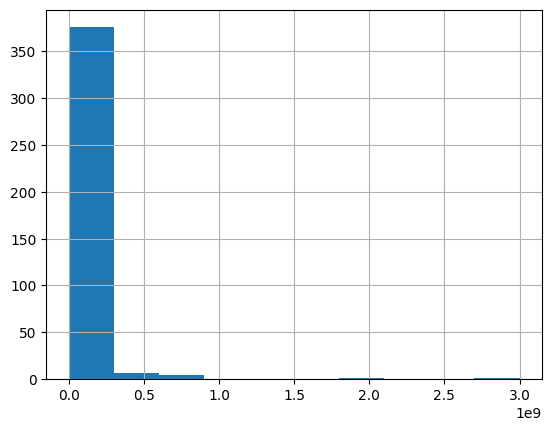

In [16]:
df['Records'].hist()

#### c. Other Data Cleaning

Just to be sure, duplicate rows were removed to avoid over-representing any breach incidents.

In [17]:
df.drop_duplicates(inplace=True)

df.value_counts()

Unnamed: 0  Entity                                  Year  Records    Organization type  Method               
0           21st Century Oncology                   2016  2200000    Healthcare         hacking-related          1
244         Premera                                 2015  11000000   Healthcare         hacking-related          1
266         Slack                                   2015  500000     Technology         poor security-related    1
265         SingHealth                              2018  1500000    Government         hacking-related          1
264         ShopBack                                2020  0          Technology         hacking-related          1
                                                                                                                ..
127         FireEye                                 2020  0          Technology         hacking-related          1
126         First American Corporation              2019  885000000  Business        

## 4. Summarizing Data

#### a. Research Question
#### **"What is the relationship between the breach method (Method) and the number of compromised records (Records), and how does this vary across different industries (Organization type)?"**

#### b. Generate Visualizations

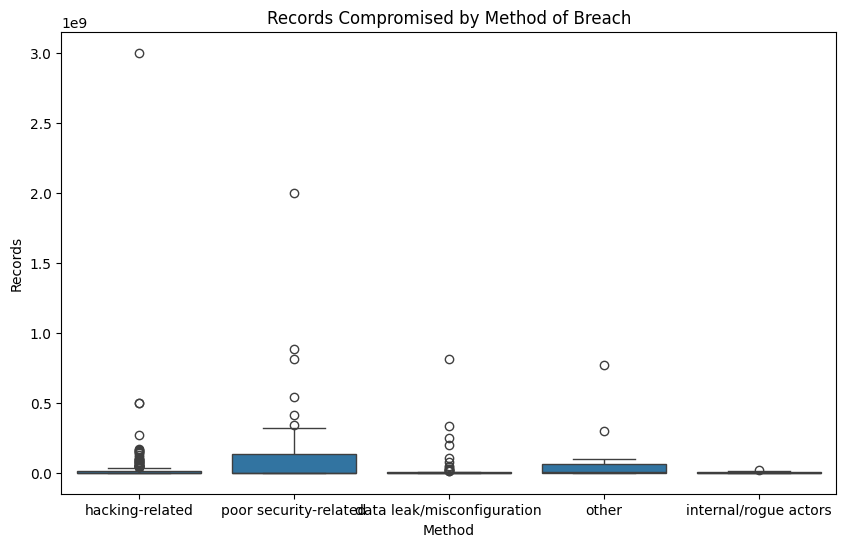

In [18]:
plt.figure(figsize=(10,6))
sns.boxplot(x='Method', y='Records', data=df)
plt.title('Records Compromised by Method of Breach')
plt.show()

As we can see, the box plot allows me to see the variation in the number of records compromised for different breach methods. For example, poor security-related cases might show the largest spread of records compromised, with a few breaches compromising millions of records. Although, there is one case in hacking has the highest compromised of them all, around about 3,000,000,000.

#### c. Summary Statistics

In [19]:
mean_records_by_method = df.groupby('Method')['Records'].mean()
mean_records_by_method

Method
data leak/misconfiguration    2.627128e+07
hacking-related               3.611589e+07
internal/rogue actors         3.406058e+06
other                         8.366407e+07
poor security-related         1.380739e+08
Name: Records, dtype: float64

In [20]:
median_records_method = df.groupby('Method')['Records'].median()
median_records_method

Method
data leak/misconfiguration     935000.0
hacking-related               1390867.5
internal/rogue actors          840000.0
other                         1818348.0
poor security-related         1289718.5
Name: Records, dtype: float64

In [21]:
mean_records_org_and_method = df.groupby(['Organization type', 'Method'])['Records'].mean()
mean_records_org_and_method

Organization type  Method                    
Business           data leak/misconfiguration    2.544046e+07
                   hacking-related               2.582964e+07
                   internal/rogue actors         5.341128e+06
                   other                         2.848000e+07
                   poor security-related         1.298688e+08
Government         data leak/misconfiguration    5.884006e+07
                   hacking-related               7.415589e+06
                   internal/rogue actors         3.344000e+05
                   other                         2.575000e+05
                   poor security-related         1.525363e+07
Healthcare         data leak/misconfiguration    1.460668e+06
                   hacking-related               1.055935e+07
                   internal/rogue actors         2.140300e+06
                   other                         0.000000e+00
                   poor security-related         2.025800e+06
Other              data 

- Data leak/Misconfiguration has the highest average number of records compromised, with a mean of 26,271,280 records. The median is lower, indicating that while most breaches involve fewer records, there are a few large-scale breaches that skew the average.
- Poor security incidents tend to involve fewer records on average compared to data leak/misconfiguration.
- Government organizations seem to be particularly vulnerable to large breaches when hacking is involved, compared to other organizations, with an average of 7,415,589 records compromised.

#### Discussion of Results
The box plot shows that poor security is associated with the widest range of compromised records, including some of the largest breaches in the dataset. On average, Data leak/Misconfiguration results in the highest number of compromised records, especially in industries like government and business. For example, government organizations see an average of over 50 million records compromised per Data leak/Misconfiguration incident.

On the other hand, breaches related to poor security tend to involve fewer compromised records. The government sector appears to have fewer records compromised per breach compared to other industries, except business, potentially due to stronger security practices that kind of dampen the damage of individual incidents.

These findings suggest that while Data leak/Misconfiguration is the most severe breach method across industries, the extent of the damage is pretty different by industry, with government and business being the most vulnerable.

## Any other type of analysis/question you want to explore with this dataset.

<u>Why?</u>: Sometimes undergraduate students will put the research projects that they did for their classes on their resumes when applying for graduate schools, internships, and jobs. If you're interested in showcasing cool analyses to write on your resume, this section could help with that. **(This section is not worth any points though).**

N/A

## 5. Conclusion

#### a. Summarization
The dataset analyzed in this project provided detailed information on major data breaches in North America, including the affected organizations, breach methods, and the number of records compromised. After cleaning the data by filling in missing values and combining similar categories, the research question explored the relationship between the method of breach and the number of compromised records, as well as how this relationship varied across industries. The results showed that data leaks and/or misconfiguraton was the most severe breach method, resulting in the highest number of compromised records, particularly in the government and business sectors. However, breaches caused by poor security typically affected fewer records. These findings highlight the importance of cybersecurity measures, especially in sectors that handle sensitive data.

#### b. Limitations
There were a few limitations in this analysis that could affect the results. First, the dataset mostly includes breaches with over 30,000 records, so smaller but still important breaches aren’t included. Also, since the data focuses on North American organizations, it doesn't give a global view of the issue. Some key details, like the number of records compromised or the method used in the breach, were missing in some cases, so we had to fill in gaps with estimates like zero or "unknown," which might affect accuracy. Finally, while we looked at the number of records compromised, we didn’t consider the financial or reputational damage these breaches caused, which would give a more complete picture of their impact.

#### c. Future Work
Future research could take this analysis further by including smaller breaches and looking at data from outside North America, giving us a more global view of the problem. Adding information about the financial and reputational damage from these breaches would also give a clearer sense of their true cost. We could even develop models to predict which industries are most likely to experience large-scale breaches based on past trends. It would also be useful to explore how effective different security measures are at preventing breaches and how long it takes organizations to recover after a breach.